# 1. Setup & Data Preparation
Importing statistical libraries, loading the cleaned dataset, and calculating the exact winter mortality rate for each apiary.

## april data

In [6]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Project paths
PROJECT_DIR = Path(r'D:\Amsterdam Uni\BEE\2026\Coding')
SRC_DIR = PROJECT_DIR / 'src'
DATA_PATH = PROJECT_DIR / 'data' / 'cleaned' / '2026_surveydata_cleaned_v2.csv'

# Make local helper module importable from the notebook, regardless of the current working directory.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import core_tools as ct

# 1. Load the cleaned data
# The CSV is not UTF-8 encoded; latin1 avoids the UnicodeDecodeError at the start of the notebook.
df = pd.read_csv(DATA_PATH, encoding='latin1')

# 2. Calculate the exact mortality rate for each apiary (Target Variable: Y)
df['mortality_rate'] = np.where(
    df['2025_winter_in'] > 0,
    ((df['2025_winter_in'] - df['2026_winter_uit']) / df['2025_winter_in']) * 100,
    0
)

# 3. Identify dummy columns safely
# First, get anything starting with food_ or varroa_
potential_dummy_cols = [col for col in df.columns if col.startswith(('food_', 'varroa_', 'methode_'))]
#potential_dummy_cols = [col for col in df.columns if col.startswith(('food_', 'varroa_'))]
# CRITICAL FIX: Only keep columns that are strictly numeric (drops any text columns automatically)
numeric_dummy_cols = df[potential_dummy_cols].select_dtypes(include=[np.number]).columns.tolist()

# Remove the base categorical columns if they sneaked in (we only want the 0/1 dummies)
cols_to_remove = ['varroa_treatment', 'winter_food']
dummy_cols = [col for col in numeric_dummy_cols if col not in cols_to_remove]

print(f"Data prepared successfully! Found {len(dummy_cols)} strictly numeric features for analysis.")
print("Features included:", dummy_cols)


Data prepared successfully! Found 7 strictly numeric features for analysis.
Features included: ['varroa_observation', 'food_1.0', 'food_3.0', 'varroa_2', 'varroa_4', 'varroa_ob_2', 'varroa_ob_4']


# 2. Correlation Matrix
Checking for multicollinearity. If variables are highly correlated with each other, it can distort the regression model.

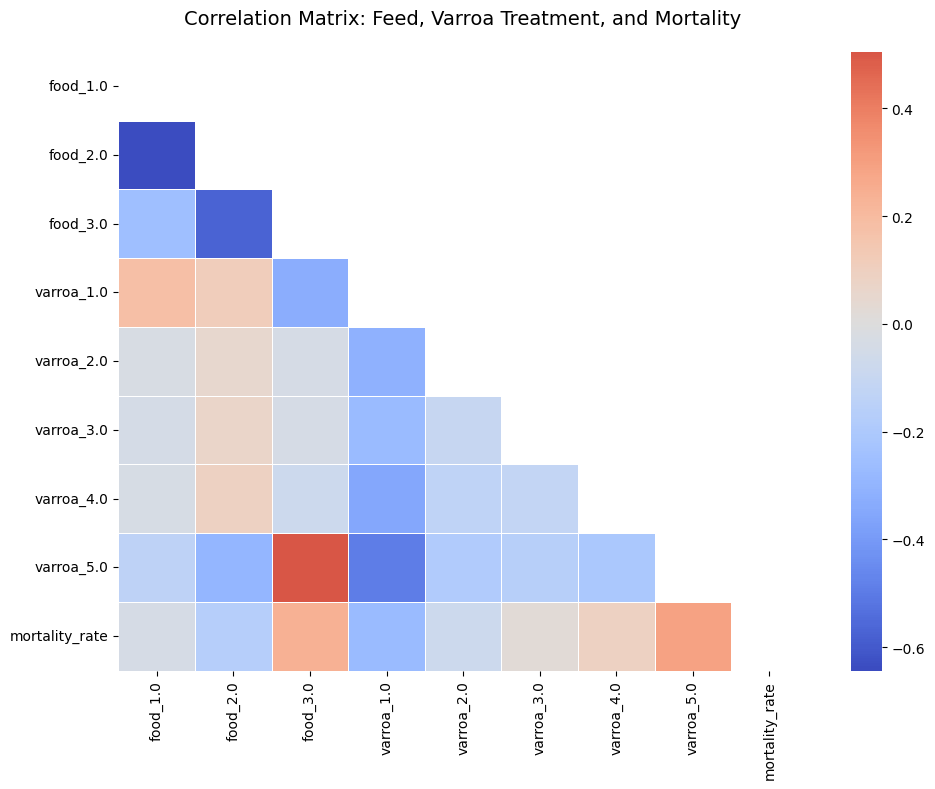

✅ Correlation matrix heatmap generated and saved to outputs/correlation_matrix_EN.csv


In [ ]:
#其实这一个热力图没用
# Extract the relevant columns for the correlation check
corr_data = df[dummy_cols + ['mortality_rate']]

# Calculate the correlation matrix (numeric_only=True acts as a double safety net)
corr_matrix = corr_data.corr(numeric_only=True)

# 制造一个“遮罩”，把右上角（包含对角线）遮住
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix: Feed, Varroa Treatment, and Mortality', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Save the matrix to the outputs folder
corr_matrix.to_csv('outputs/correlation_matrix_EN.csv')
print("✅ Correlation matrix heatmap generated and saved to outputs/correlation_matrix_EN.csv")

## april data

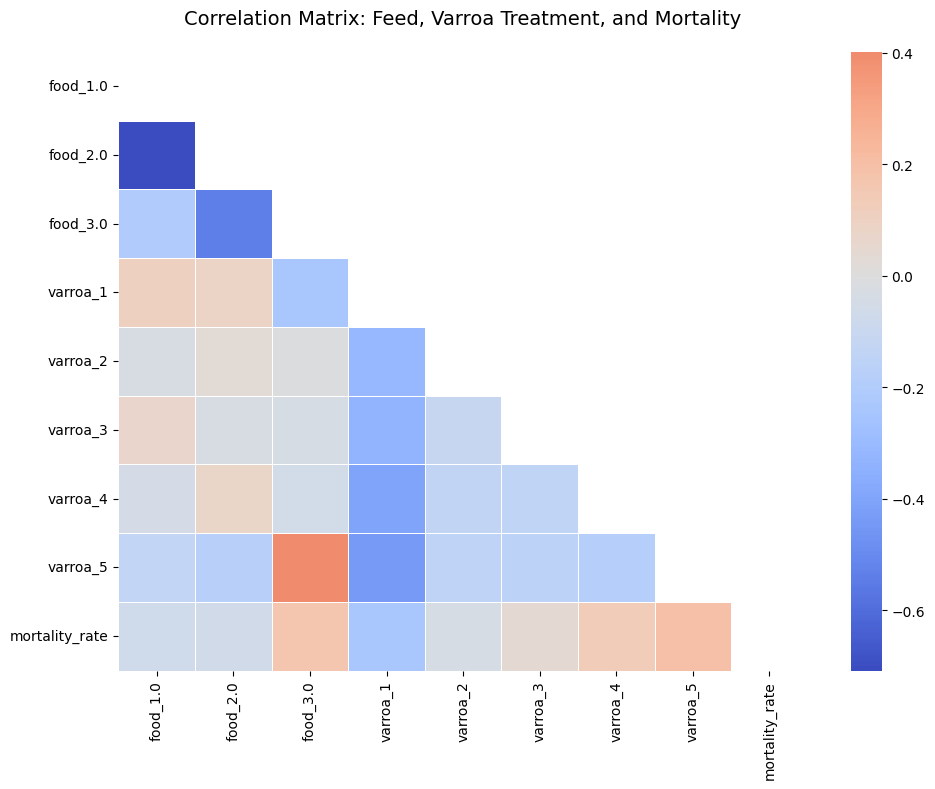

✅ Correlation matrix heatmap generated and saved to outputs/correlation_matrix_EN.csv


In [2]:
#其实这一个热力图没用
# Extract the relevant columns for the correlation check
corr_data = df[dummy_cols + ['mortality_rate']]

# Calculate the correlation matrix (numeric_only=True acts as a double safety net)
corr_matrix = corr_data.corr(numeric_only=True)

# 制造一个“遮罩”，把右上角（包含对角线）遮住
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix: Feed, Varroa Treatment, and Mortality', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Save the matrix to the outputs folder
corr_matrix.to_csv('outputs/correlation_matrix_EN.csv')
print("✅ Correlation matrix heatmap generated and saved to outputs/correlation_matrix_EN.csv")

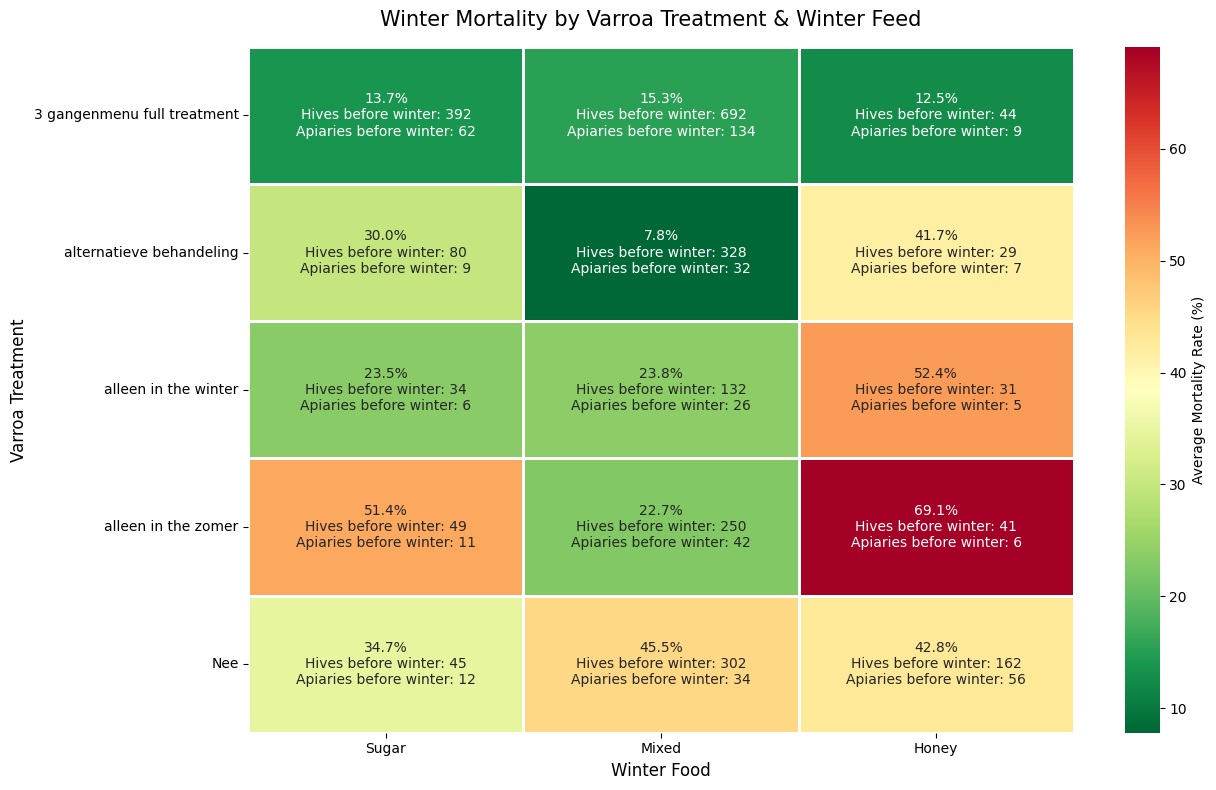

In [14]:
import numpy as np # 确保导入了 numpy

# --- Advanced Combination Analysis: Mortality + Sample Sizes ---

# 1. Calculate THREE separate Pivot Tables
# Table A: Average Mortality
pivot_mort = df.pivot_table(values='mortality_rate', index='varroa_treatment', columns='winter_food', aggfunc='mean')
# Table B: Total Hives (Sum of 2025_winter_in)
pivot_hives = df.pivot_table(values='2025_winter_in', index='varroa_treatment', columns='winter_food', aggfunc='sum')
# Table C: Total Locations/Apiaries (Count of rows)
pivot_locs = df.pivot_table(values='2025_winter_in', index='varroa_treatment', columns='winter_food', aggfunc='count')

# Map the numeric codes to readable text labels for all tables
for pt in [pivot_mort, pivot_hives, pivot_locs]:
    pt.index = pt.index.astype(int).map(ct.varroa_treatment_dict)
    pt.columns = pt.columns.astype(int).map(ct.winter_food_dict)

# 2. Create Custom Text Labels combining all three metrics
annot_labels = []
for i in range(pivot_mort.shape[0]):
    row_labels = []
    for j in range(pivot_mort.shape[1]):
        mort = pivot_mort.iloc[i, j]
        hives = pivot_hives.iloc[i, j]
        locs = pivot_locs.iloc[i, j]
        
        # If there is no data for a combination, show N/A
        if pd.isna(mort):
            row_labels.append("N/A")
        else:
            # Format: 15.2% \n Hives: 1,200 \n Locs: 45
            label = f"{mort:.1f}%\nHives before winter: {int(hives):,}\nApiaries before winter: {int(locs):,}"
            row_labels.append(label)
    annot_labels.append(row_labels)

# 3. Draw the Enhanced Heatmap
plt.figure(figsize=(13, 8)) 

# Use fmt="" because our labels are custom strings, not raw numbers
sns.heatmap(pivot_mort, annot=annot_labels, fmt="", cmap="RdYlGn_r", 
            cbar_kws={'label': 'Average Mortality Rate (%)'}, 
            linewidths=1, linecolor='white', annot_kws={"size": 10})

plt.title('Winter Mortality by Varroa Treatment & Winter Feed   ', fontsize=15, pad=15)
plt.ylabel('Varroa Treatment', fontsize=12)
plt.xlabel('Winter Food', fontsize=12)

plt.yticks(rotation=0) 
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

## april data

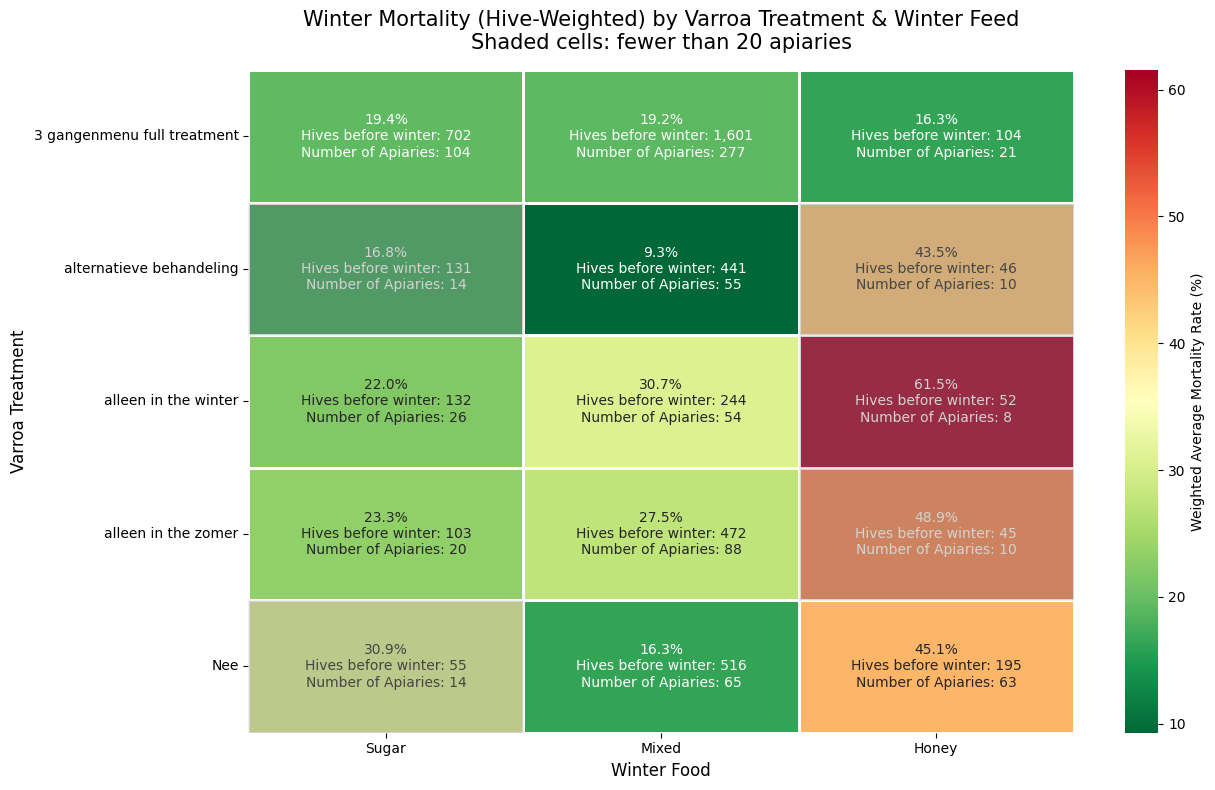

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Advanced Combination Analysis: Hive-weighted mortality + low-sample shading ---

PROJECT_DIR = Path(r'D:\Amsterdam Uni\BEE\2026\Coding')
SRC_DIR = PROJECT_DIR / 'src'
DATA_PATH = PROJECT_DIR / 'data' / 'cleaned' / '2026_surveydata_cleaned_v2.csv'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import core_tools as ct

# Let this cell run even if the setup cell has not been executed in the current kernel.
if 'df' not in globals():
    df = pd.read_csv(DATA_PATH, encoding='latin1')

# 1. Calculate pivot tables for each Varroa treatment x Winter food combination.
pivot_hives_in = df.pivot_table(
    values='2025_winter_in',
    index='varroa_treatment',
    columns='winter_food',
    aggfunc='sum'
)
pivot_hives_out = df.pivot_table(
    values='2026_winter_uit',
    index='varroa_treatment',
    columns='winter_food',
    aggfunc='sum'
)

# Hive-weighted mortality: (sum winter in - sum winter out) / sum winter in * 100
pivot_weighted_mort = ((pivot_hives_in - pivot_hives_out) / pivot_hives_in.replace(0, np.nan)) * 100

# Number of apiaries in each cell; cells below this threshold get a transparent grey shade.
pivot_locs = df.pivot_table(
    values='2025_winter_in',
    index='varroa_treatment',
    columns='winter_food',
    aggfunc='count'
)
min_apiaries = 20

# Map numeric IDs to readable labels for all aligned tables.
for pt in [pivot_weighted_mort, pivot_hives_in, pivot_locs]:
    pt.index = pt.index.astype(int).map(ct.varroa_treatment_dict)
    pt.columns = pt.columns.astype(int).map(ct.winter_food_dict)

shade_mask = (pivot_locs < min_apiaries).fillna(False)

# 2. Create custom text labels. Low-sample cells keep their labels; the shade is only visual.
annot_labels = []
for i in range(pivot_weighted_mort.shape[0]):
    row_labels = []
    for j in range(pivot_weighted_mort.shape[1]):
        mort = pivot_weighted_mort.iloc[i, j]
        hives = pivot_hives_in.iloc[i, j]
        locs = pivot_locs.iloc[i, j]
        
        if pd.isna(mort):
            row_labels.append("")
        else:
            label = f"{mort:.1f}%\nHives before winter: {int(hives):,}\nNumber of Apiaries: {int(locs):,}"
            row_labels.append(label)
    annot_labels.append(row_labels)

# 3. Draw the heatmap normally, then add transparent grey shading for low-sample cells.
fig, ax = plt.subplots(figsize=(13, 8))

sns.heatmap(
    pivot_weighted_mort,
    annot=np.array(annot_labels),
    fmt="",
    cmap="RdYlGn_r",
    cbar_kws={'label': 'Weighted Average Mortality Rate (%)'},
    linewidths=1,
    linecolor='white',
    annot_kws={"size": 10},
    ax=ax
)

# Transparent overlay: keeps the original heatmap color visible, but visually de-emphasizes low-apiary cells.
for row_idx, col_idx in zip(*np.where(shade_mask.to_numpy())):
    ax.add_patch(
        plt.Rectangle(
            (col_idx, row_idx),
            1,
            1,
            facecolor='grey',
            alpha=0.35,
            edgecolor='white',
            linewidth=1.0,
            zorder=3
        )
    )

ax.set_title(
    f'Winter Mortality (Hive-Weighted) by Varroa Treatment & Winter Feed\nShaded cells: fewer than {min_apiaries} apiaries',
    fontsize=15,
    pad=15
)
ax.set_ylabel('Varroa Treatment', fontsize=12)
ax.set_xlabel('Winter Food', fontsize=12)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


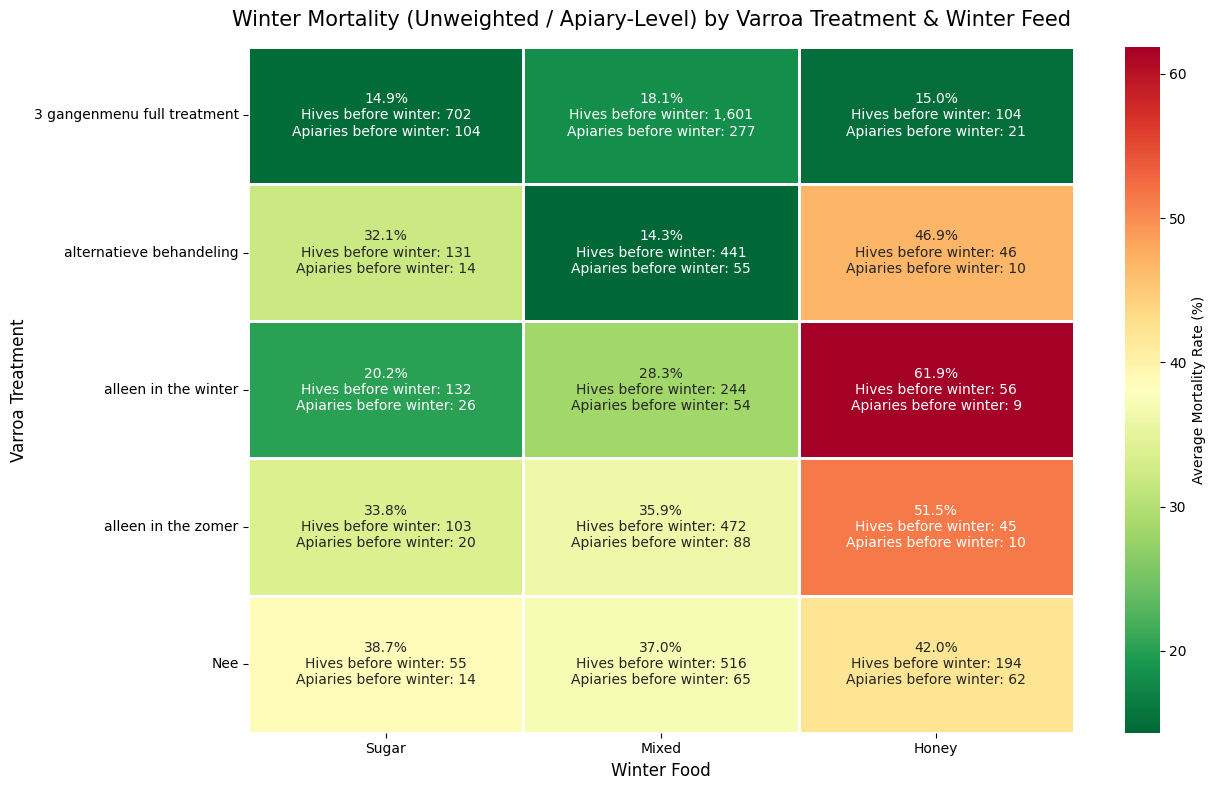

In [11]:
import numpy as np # 确保导入了 numpy
import core_tools as ct

# --- Advanced Combination Analysis: Mortality + Sample Sizes ---

# 1. Calculate THREE separate Pivot Tables
# Table A: Average Mortality
pivot_mort = df.pivot_table(values='mortality_rate', index='varroa_treatment', columns='winter_food', aggfunc='mean')
# Table B: Total Hives (Sum of 2025_winter_in)
pivot_hives = df.pivot_table(values='2025_winter_in', index='varroa_treatment', columns='winter_food', aggfunc='sum')
# Table C: Total Locations/Apiaries (Count of rows)
pivot_locs = df.pivot_table(values='2025_winter_in', index='varroa_treatment', columns='winter_food', aggfunc='count')

# Map the numeric codes to readable text labels for all tables
for pt in [pivot_mort, pivot_hives, pivot_locs]:
    pt.index = pt.index.astype(int).map(ct.varroa_treatment_dict)
    pt.columns = pt.columns.astype(int).map(ct.winter_food_dict)

# 2. Create Custom Text Labels combining all three metrics
annot_labels = []
for i in range(pivot_mort.shape[0]):
    row_labels = []
    for j in range(pivot_mort.shape[1]):
        mort = pivot_mort.iloc[i, j]
        hives = pivot_hives.iloc[i, j]
        locs = pivot_locs.iloc[i, j]
        
        # If there is no data for a combination, show N/A
        if pd.isna(mort):
            row_labels.append("N/A")
        else:
            # Format: 15.2% \n Hives: 1,200 \n Locs: 45
            label = f"{mort:.1f}%\nHives before winter: {int(hives):,}\nApiaries before winter: {int(locs):,}"
            row_labels.append(label)
    annot_labels.append(row_labels)

# 3. Draw the Enhanced Heatmap
plt.figure(figsize=(13, 8)) 

# Use fmt="" because our labels are custom strings, not raw numbers
sns.heatmap(pivot_mort, annot=annot_labels, fmt="", cmap="RdYlGn_r", 
            cbar_kws={'label': 'Average Mortality Rate (%)'}, 
            linewidths=1, linecolor='white', annot_kws={"size": 10})

plt.title('Winter Mortality (Unweighted / Apiary-Level) by Varroa Treatment & Winter Feed   ', fontsize=15, pad=15)
plt.ylabel('Varroa Treatment', fontsize=12)
plt.xlabel('Winter Food', fontsize=12)

plt.yticks(rotation=0) 
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

In [15]:
# --- Deep Dive: Profiling the "Golden Cohort" ---

# 1. Isolate the "Golden Cohort"
# (Assuming 2 represents 'alternatieve behandeling' and 2 represents 'Mixed'. Update if your dict differs)
golden_cohort = df[(df['varroa_treatment'] == 2) & (df['winter_food'] == 2)].copy()

print(f"Golden cohort isolated successfully! Found {len(golden_cohort)} apiaries.\n")

# 2. Check: Is the low mortality driven by one massive commercial operation?
print("--- 1. Hive Size Distribution ---")
# Look at the mean and max to see if these are commercial giants or backyard hobbyists
print(golden_cohort['2025_winter_in'].describe()[['mean', 'min', 'max']])

# 3. Check: What is the preferred beekeeping method of these 32 experts?
# (Let's bring back the 'imker_methode' we temporarily excluded from the regression)
print("\n--- 2. Beekeeping Method Preference (Imker Methode) ---")
# Map the numeric codes back to text labels using your dictionary
methode_counts = golden_cohort['imker_methode'].map(ct.imker_methode_dict).value_counts()
print(methode_counts)

Golden cohort isolated successfully! Found 55 apiaries.

--- 1. Hive Size Distribution ---
mean      8.018182
min       1.000000
max     100.000000
Name: 2025_winter_in, dtype: float64

--- 2. Beekeeping Method Preference (Imker Methode) ---
imker_methode
Regulier             25
Unknown and Mixed    20
Controlled            7
Natural               3
Name: count, dtype: int64


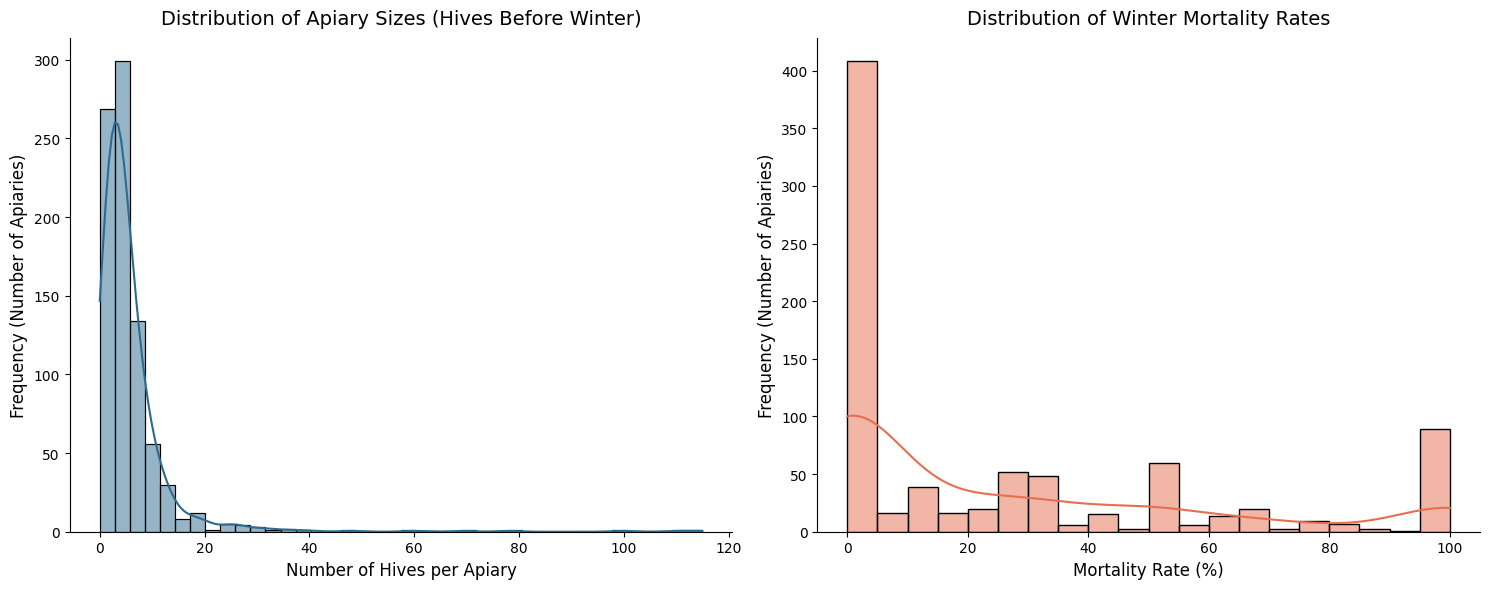

✅ Distribution charts generated and saved to outputs/distribution_charts_EN.png


In [16]:
# --- Exploratory Data Analysis: Distributions ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a side-by-side figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 1. Distribution of Hive Sizes (Apiary Size) ---
# Using a histogram with a KDE (Kernel Density Estimate) line to show the trend
sns.histplot(df['2025_winter_in'], bins=40, kde=True, color='#2C6B8E', ax=axes[0])
axes[0].set_title('Distribution of Apiary Sizes (Hives Before Winter)', fontsize=14, pad=10)
axes[0].set_xlabel('Number of Hives per Apiary', fontsize=12)
axes[0].set_ylabel('Frequency (Number of Apiaries)', fontsize=12)

# --- 2. Distribution of Mortality Rates ---
sns.histplot(df['mortality_rate'], bins=20, kde=True, color='#E76F51', ax=axes[1])
axes[1].set_title('Distribution of Winter Mortality Rates', fontsize=14, pad=10)
axes[1].set_xlabel('Mortality Rate (%)', fontsize=12)
axes[1].set_ylabel('Frequency (Number of Apiaries)', fontsize=12)

# Clean up the borders for a modern look
sns.despine()
plt.tight_layout()
plt.show()

# Optional: Save the figure for your report
fig.savefig('outputs/distribution_charts_EN.png', dpi=300, bbox_inches='tight')
print("✅ Distribution charts generated and saved to outputs/distribution_charts_EN.png")

# 3. Multiple Linear Regression Model (OLS)
Running the regression to measure the isolated impact of Winter Feed and Varroa Treatment on hive mortality.

**Baselines (Reference Groups) excluded from the model to avoid the Dummy Variable Trap:**
* **Winter Feed Baseline:** `Sugar` (1)
* **Varroa Treatment Baseline:** `Nee / No Treatment` (5)

In [17]:
# --- 4. Advanced Modeling: GEE / Binomial GLM (Clustered by Beekeeper) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

print("Preparing data for the Binomial GEE Model...")

# 1. Prepare the Binomial Target Variables (Y)
model_df = df.copy()
model_df['deaths'] = model_df['2025_winter_in'] - model_df['2026_winter_uit']
model_df['survivors'] = model_df['2026_winter_uit']

# Filter out rows with 0 initial hives, AND ensure 'id_beekeeper' exists
model_df = model_df[(model_df['2025_winter_in'] > 0) & (model_df['id_beekeeper'].notna())]

Y_binomial = model_df[['deaths', 'survivors']]

# 2. Define the Independent Variables (X)
# We strictly exclude our chosen baselines (Sugar and Nee and Controlled)
baselines_to_exclude = ['food_1', 'food_1.0', 'varroa_5', 'varroa_5.0', 'methode_1', 'methode_1.0']
features_to_include = [col for col in dummy_cols if col not in baselines_to_exclude]

X_binomial = model_df[features_to_include]


# [NEW] 2.5 Create Interaction Terms: Food * Varroa Treatment
# We cross-multiply every food dummy with every varroa dummy
food_vars = [col for col in dummy_cols if 'food' in col and col not in baselines_to_exclude]
varroa_vars = [col for col in dummy_cols if 'varroa' in col and col not in baselines_to_exclude]

for f in food_vars:
    for v in varroa_vars:
        interaction_name = f"{f}_X_{v}" # Example: food_2.0_X_varroa_2.0
        X_binomial[interaction_name] = X_binomial[f] * X_binomial[v]


# Add Intercept
X_binomial = sm.add_constant(X_binomial)

# Safety check: Drop missing values to ensure the model runs smoothly
clean_idx = X_binomial.dropna().index
Y_clean = Y_binomial.loc[clean_idx]
X_clean = X_binomial.loc[clean_idx]

# 3. [CRITICAL UPDATE] Define Groups for GEE
# Treat all apiaries owned by the SAME BEEKEEPER as a single clustered group
groups = model_df.loc[clean_idx, 'id_beekeeper']

# 4. Run the GEE Model
print("\nRunning Generalized Estimating Equations (GEE) Model...")
gee_model_interact = sm.GEE(
    endog=Y_clean, 
    exog=X_clean, 
    groups=groups, 
    family=sm.families.Binomial()
).fit()

# 5. Print the Professional Output
print("==============================================================================")
print("   GEE BINOMIAL REGRESSION RESULTS (CLUSTERED BY BEEKEEPER, with Interactions)")
print("==============================================================================")
print(gee_model_interact.summary())
print("==============================================================================")

# 6. Calculate Odds Ratios (easier to interpret for business)
odds_ratios = pd.DataFrame({
    'Odds Ratio': np.exp(gee_model_interact.params),
    'P-Value': gee_model_interact.pvalues
})
print("\n--- ODDS RATIOS (For easier interpretation) ---")
print("Note: An Odds Ratio < 1 means LOWER mortality risk compared to the baseline.")
print(odds_ratios.round(4))

# Save results
odds_ratios.to_csv('outputs/gee_odds_ratios_beekeeper_interact_EN.csv')
print("\n✅ GEE results successfully saved!")

Preparing data for the Binomial GEE Model...

Running Generalized Estimating Equations (GEE) Model...
   GEE BINOMIAL REGRESSION RESULTS (CLUSTERED BY BEEKEEPER, with Interactions)
                                GEE Regression Results                                
Dep. Variable:        ['deaths', 'survivors']   No. Observations:                  828
Model:                                    GEE   No. clusters:                      693
Method:                           Generalized   Min. cluster size:                   1
                         Estimating Equations   Max. cluster size:                  31
Family:                              Binomial   Mean cluster size:                 1.2
Dependence structure:            Independence   Num. iterations:                     2
Date:                        Sun, 19 Apr 2026   Scale:                           1.000
Covariance type:                       robust   Time:                         21:20:06
                          coef    st

C:\Users\Nora-\AppData\Local\Temp\ipykernel_26572\2256497569.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_binomial[interaction_name] = X_binomial[f] * X_binomial[v]
C:\Users\Nora-\AppData\Local\Temp\ipykernel_26572\2256497569.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_binomial[interaction_name] = X_binomial[f] * X_binomial[v]
C:\Users\Nora-\AppData\Local\Temp\ipykernel_26572\2256497569.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr


✅ GEE results successfully saved!


## april data

In [35]:
# --- 4. Advanced Modeling: GEE / Binomial GLM (Clustered by Beekeeper) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

print("Preparing data for the Binomial GEE Model...")

# 1. Prepare the Binomial Target Variables (Y)
model_df = df.copy()
model_df['deaths'] = model_df['2025_winter_in'] - model_df['2026_winter_uit']
model_df['survivors'] = model_df['2026_winter_uit']

# Filter out rows with 0 initial hives, AND ensure 'id_beekeeper' exists
model_df = model_df[(model_df['2025_winter_in'] > 0) & (model_df['id_beekeeper'].notna())]

Y_binomial = model_df[['deaths', 'survivors']]

# 2. Define the Independent Variables (X)
# We strictly exclude our chosen baselines (Sugar and Nee and Controlled)
baselines_to_exclude = ['methode_1','methode_1.0','food_2', 'food_2.0', 'varroa_2', 'varroa_2.0']

#baselines_to_exclude = ['food_2', 'food_2.0', 'varroa_2', 'varroa_2.0']
features_to_include = [col for col in dummy_cols if col not in baselines_to_exclude]

X_binomial = model_df[features_to_include]


# [NEW] 2.5 Create Interaction Terms: Food * Varroa Treatment
# We cross-multiply every food dummy with every varroa dummy
food_vars = [col for col in dummy_cols if 'food' in col and col not in baselines_to_exclude]
varroa_vars = [col for col in dummy_cols if 'varroa' in col and col not in baselines_to_exclude]

for f in food_vars:
    for v in varroa_vars:
        interaction_name = f"{f}_X_{v}" # Example: food_2.0_X_varroa_2.0
        X_binomial[interaction_name] = X_binomial[f] * X_binomial[v]



# Add Intercept
X_binomial = sm.add_constant(X_binomial)

# Safety check: Drop missing values to ensure the model runs smoothly
clean_idx = X_binomial.dropna().index
Y_clean = Y_binomial.loc[clean_idx]
X_clean = X_binomial.loc[clean_idx]

# 3. [CRITICAL UPDATE] Define Groups for GEE
# Treat all apiaries owned by the SAME BEEKEEPER as a single clustered group
groups = model_df.loc[clean_idx, 'id_beekeeper']

# 4. Run the GEE Model
print("\nRunning Generalized Estimating Equations (GEE) Model...")
gee_model_interact = sm.GEE(
    endog=Y_clean, 
    exog=X_clean, 
    groups=groups, 
    family=sm.families.Binomial()
).fit()

# 5. Print the Professional Output
print("==============================================================================")
print("   GEE BINOMIAL REGRESSION RESULTS (CLUSTERED BY BEEKEEPER, with Interactions)")
print("==============================================================================")
print(gee_model_interact.summary())
print("==============================================================================")

# 6. Calculate Odds Ratios (easier to interpret for business)
odds_ratios = pd.DataFrame({
    'Odds Ratio': np.exp(gee_model_interact.params),
    'P-Value': gee_model_interact.pvalues
})
print("\n--- ODDS RATIOS (For easier interpretation) ---")
print("Note: An Odds Ratio < 1 means LOWER mortality risk compared to the baseline.")
print(odds_ratios.round(4))

#基准组：method_1:controller；food_2:sugar+honey;varroa_2:'alternatieve behandeling'
# Save results
odds_ratios.to_csv('outputs/gee_odds_ratios_beekeeper_less_interacts_EN.csv')
print("\n✅ GEE results successfully saved!")

Preparing data for the Binomial GEE Model...

Running Generalized Estimating Equations (GEE) Model...


C:\Users\Nora-\AppData\Local\Temp\ipykernel_26572\1244078493.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_binomial[interaction_name] = X_binomial[f] * X_binomial[v]
C:\Users\Nora-\AppData\Local\Temp\ipykernel_26572\1244078493.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_binomial[interaction_name] = X_binomial[f] * X_binomial[v]
C:\Users\Nora-\AppData\Local\Temp\ipykernel_26572\1244078493.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

   GEE BINOMIAL REGRESSION RESULTS (CLUSTERED BY BEEKEEPER, with Interactions)
                                GEE Regression Results                                
Dep. Variable:        ['deaths', 'survivors']   No. Observations:                  828
Model:                                    GEE   No. clusters:                      693
Method:                           Generalized   Min. cluster size:                   1
                         Estimating Equations   Max. cluster size:                  31
Family:                              Binomial   Mean cluster size:                 1.2
Dependence structure:            Independence   Num. iterations:                     2
Date:                        Mon, 20 Apr 2026   Scale:                           1.000
Covariance type:                       robust   Time:                         10:05:13
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

In [36]:
import pickle

# 将模型对象保存到名为 'gee_model.pkl' 的文件中
with open('gee_model_interact.pkl', 'wb') as f:
    pickle.dump(gee_model_interact, f)

print("saved as gee_model_interact.pkl")

saved as gee_model_interact.pkl


In [32]:
print("\nBeekeeping Method Mapping:")
print(ct.imker_methode_dict)
print("\nFood Mapping:")
print(ct.winter_food_dict)
print("\nVarroa Treatment Mapping:")
print(ct.varroa_treatment_dict)


Beekeeping Method Mapping:
{1: 'Controlled', 2: 'Natural', 3: 'Regulier', 4: 'Unknown and Mixed'}

Food Mapping:
{1: 'Sugar', 2: 'Mixed', 3: 'Honey'}

Varroa Treatment Mapping:
{1: '3 gangenmenu full treatment', 2: 'alternatieve behandeling', 3: 'alleen in the winter', 4: 'alleen in the zomer', 5: 'Nee'}


In [27]:
df

,id_location,timestamp,id_beekeeper,email,imkervereniging,imker_year_origin,imker_year,imker_methode_origin,imker_methode,bijenstanden_count_origin,...,methode_4,food_1.0,food_2.0,food_3.0,varroa_1,varroa_2,varroa_3,varroa_4,varroa_5,mortality_rate
0,1,2026-04-07 19:05:33,1,evandermeer1966@gmail.com,"Imkersvereniging Amstelland, Amstelveen",2009,2009,Ik imker regulier,3,4,...,0,0,1,0,1,0,0,0,0,50.000000
1,2,2026-04-07 19:01:58,1,evandermeer1966@gmail.com,"Imkersvereniging Amstelland, Amstelveen",2009,2009,Ik imker regulier,3,4,...,0,0,1,0,0,1,0,0,0,0.000000
2,3,2026-04-07 18:56:25,1,evandermeer1966@gmail.com,"Imkersvereniging Amstelland, Amstelveen",2009,2009,Ik imker regulier,3,4,...,0,0,1,0,1,0,0,0,0,0.000000
3,4,2026-04-07 18:46:48,1,evandermeer1966@gmail.com,"Imkersvereniging Amstelland, Amstelveen",2009,2009,Ik imker regulier,3,4,...,0,0,1,0,1,0,0,0,0,9.090909
4,5,2026-04-07 10:41:33,2,nelleke.vanrijnsoever@upcmail.nl,Haarlem en omgeving,2020,2020,Ik imker regulier,3,1,...,0,0,1,0,0,0,0,0,1,66.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,840,NaN,706,b.strijker@odin.nl,BD imkers,2014,2014,Biodynamisch imkeren,2,34,...,0,0,0,1,0,0,0,0,1,25.000000
828,841,NaN,706,b.strijker@odin.nl,BD imkers,2014,2014,Biodynamisch imkeren,2,34,...,0,0,0,1,0,0,0,0,1,66.666667
829,842,NaN,706,b.strijker@odin.nl,BD imkers,2014,2014,Biodynamisch imkeren,2,34,...,0,0,0,1,0,0,0,0,1,0.000000
830,843,NaN,706,b.strijker@odin.nl,BD imkers,2014,2014,Biodynamisch imkeren,2,34,...,0,0,0,1,0,0,0,0,1,50.000000
